# Generación de un conjunto sintético para detección binaria y localización temporal usando `dx(t)`

Este cuaderno documenta la construcción de un conjunto sintético destinado a la segunda fase experimental del proyecto. En esta etapa se consideran trayectorias con y sin punto de cambio, lo que permite formular el análisis como una tarea compuesta por detección binaria y localización temporal.

La representación principal se basa en los incrementos `dx(t) = x(t+1) - x(t)`, en lugar de utilizar directamente la posición `x(t)`. Esta elección centra el aprendizaje posterior en las variaciones locales de la trayectoria, que resultan especialmente relevantes para caracterizar cambios de régimen en procesos de difusión anómala.

El conjunto conserva los cinco modelos de difusión anómala utilizados en el proyecto y organiza las etiquetas necesarias para distinguir trayectorias homogéneas de trayectorias con transición real.


## 1. Importación de dependencias

Se cargan las librerías necesarias para gestionar rutas, leer y validar archivos HDF5, organizar resúmenes tabulares y preparar la representación basada en incrementos.

Estas dependencias permiten separar la simulación del conjunto sintético de su posterior inspección metodológica.

In [1]:
import os
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2. Diseño experimental

Todas las trayectorias conservan una longitud `L = 100`. En las trayectorias con punto de cambio, la transición se sitúa dentro del intervalo permitido para garantizar que existan observaciones suficientes antes y después del cambio. En las trayectorias sin punto de cambio, toda la secuencia procede de un único modelo de difusión anómala.

El conjunto se construye de forma equilibrada entre trayectorias con y sin punto de cambio. Además, dentro del grupo sin punto de cambio, los modelos `ATTM`, `CTRW`, `FBM`, `LW` y `SBM` aparecen con frecuencias comparables.

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data_synthetic_with_without_changepoint_dx"
SCRIPT_PATH = PROJECT_ROOT / "scripts" / "build_synthetic_with_without_changepoint_dx.py"

TRAJECTORY_LENGTH = int(os.getenv("TRAJECTORY_LENGTH", "100"))
DX_LENGTH = TRAJECTORY_LENGTH - 1
MIN_SEGMENT_LENGTH = int(round(0.20 * TRAJECTORY_LENGTH))
DIMENSION = 1

MODELS = ["ATTM", "CTRW", "FBM", "LW", "SBM"]
MODEL_TO_ID = {model: index for index, model in enumerate(MODELS)}
ID_TO_MODEL = {index: model for model, index in MODEL_TO_ID.items()}

WITH_CHANGE_TRANSITIONS = [(m1, m2) for m1 in MODELS for m2 in MODELS if m1 != m2]
WITHOUT_CHANGE_TRANSITIONS = [(model, model) for model in MODELS]

SPLIT_SIZES = {
    "train": {"with_per_transition": 5_000, "without_per_model": 20_000},
    "val": {"with_per_transition": 500, "without_per_model": 2_000},
    "test": {"with_per_transition": 5_000, "without_per_model": 20_000},
}

summary_rows = []
for split, config in SPLIT_SIZES.items():
    with_count = len(WITH_CHANGE_TRANSITIONS) * config["with_per_transition"]
    without_count = len(WITHOUT_CHANGE_TRANSITIONS) * config["without_per_model"]
    summary_rows.append({
        "split": split,
        "with_changepoint": with_count,
        "without_changepoint": without_count,
        "total": with_count + without_count,
    })

pd.DataFrame(summary_rows)

,split,with_changepoint,without_changepoint,total
0,train,100000,100000,200000
1,val,10000,10000,20000
2,test,100000,100000,200000


## 3. Generación de las particiones HDF5

La simulación se realiza mediante un script independiente para mantener separadas la producción de datos y la validación del conjunto generado. El procedimiento crea tres archivos HDF5 correspondientes a las particiones de entrenamiento, validación y test.

Cada archivo contiene las variables necesarias para el análisis posterior, entre ellas `X`, `dx`, `has_changepoint`, `cp`, `cp_dx`, `cp_dx_norm`, `model1`, `model2`, `alpha1`, `alpha2` y `noise_sigma`. La celda siguiente muestra el comando de generación utilizado por el notebook.

In [3]:
generation_command = (
    f'python "{SCRIPT_PATH}" '
    f'--output-dir "{DATA_DIR}" '
    f'--length {TRAJECTORY_LENGTH} '
    f'--minimum-segment-length {MIN_SEGMENT_LENGTH} '
    f'--dimension {DIMENSION}'
)

print(generation_command)
print(generation_command + " --dry-run")

python "C:\Users\chair\Downloads\changepoint_new_phase_files\scripts\build_synthetic_with_without_changepoint_dx.py" --output-dir "C:\Users\chair\Downloads\changepoint_new_phase_files\data_synthetic_with_without_changepoint_dx" --length 100 --minimum-segment-length 20 --dimension 1
python "C:\Users\chair\Downloads\changepoint_new_phase_files\scripts\build_synthetic_with_without_changepoint_dx.py" --output-dir "C:\Users\chair\Downloads\changepoint_new_phase_files\data_synthetic_with_without_changepoint_dx" --length 100 --minimum-segment-length 20 --dimension 1 --dry-run


La ejecución completa de la simulación se controla mediante la variable `RUN_GENERATION`. Esta opción evita regenerar accidentalmente un conjunto costoso cuando los archivos ya existen.

Para producir una nueva versión del conjunto sintético, se activa esta variable y se ejecuta la celda correspondiente. Para una verificación preliminar, puede utilizarse una ejecución reducida antes de lanzar la generación completa.

In [4]:
RUN_GENERATION = False

if RUN_GENERATION:
    import subprocess
    subprocess.run(generation_command, shell=True, check=True)

## 4. Verificación de archivos generados

Se comprueba la disponibilidad de las particiones esperadas en la carpeta de datos. Esta revisión permite continuar con la validación y el análisis sin repetir la simulación cuando los archivos HDF5 ya han sido creados.

La comprobación actúa como control inicial de reproducibilidad del flujo de trabajo.

In [5]:
dataset_files = {
    "train": DATA_DIR / f"train_L{TRAJECTORY_LENGTH}_dim{DIMENSION}_with_without_dx.h5",
    "val": DATA_DIR / f"val_L{TRAJECTORY_LENGTH}_dim{DIMENSION}_with_without_dx.h5",
    "test": DATA_DIR / f"test_L{TRAJECTORY_LENGTH}_dim{DIMENSION}_with_without_dx.h5",
}

pd.DataFrame({
    "split": list(dataset_files.keys()),
    "path": [str(path) for path in dataset_files.values()],
    "available": [path.exists() for path in dataset_files.values()],
})

,split,path,available
0,train,C:\Users\chair\Downloads\changepoint_new_phase...,True
1,val,C:\Users\chair\Downloads\changepoint_new_phase...,True
2,test,C:\Users\chair\Downloads\changepoint_new_phase...,True


## 5. Organización interna de los archivos HDF5

La variable `dx` constituye la entrada principal de los modelos entrenados en los cuadernos posteriores. La variable `has_changepoint` indica si la trayectoria contiene un punto de cambio real.

Para las trayectorias sin punto de cambio se conserva `cp = -1`, mientras que para las trayectorias con cambio se almacena la posición real en la trayectoria original y su índice equivalente en la serie de incrementos mediante `cp_dx = cp - 1`. Esta convención mantiene la coherencia entre la representación `x(t)` y la entrada `dx(t)`.

In [6]:
dataset_overview = []

for split, file_path in dataset_files.items():
    if not file_path.exists():
        dataset_overview.append({"split": split, "available": False})
        continue

    with h5py.File(file_path, "r") as file:
        has_cp = file["has_changepoint"][:]
        dataset_overview.append({
            "split": split,
            "available": True,
            "X_shape": file["X"].shape,
            "dx_shape": file["dx"].shape,
            "with_changepoint": int(has_cp.sum()),
            "without_changepoint": int((1 - has_cp).sum()),
            "cp_min_with_change": int(file["cp"][:][has_cp == 1].min()) if has_cp.sum() else None,
            "cp_max_with_change": int(file["cp"][:][has_cp == 1].max()) if has_cp.sum() else None,
        })

pd.DataFrame(dataset_overview)

,split,available,X_shape,dx_shape,with_changepoint,without_changepoint,cp_min_with_change,cp_max_with_change
0,train,True,"(200000, 100, 1)","(200000, 99, 1)",100000,100000,20,80
1,val,True,"(20000, 100, 1)","(20000, 99, 1)",10000,10000,20,80
2,test,True,"(200000, 100, 1)","(200000, 99, 1)",100000,100000,20,80


## 6. Equilibrio entre clases y modelos

El conjunto se revisa en dos niveles: primero, el equilibrio entre trayectorias con y sin punto de cambio; segundo, la distribución de los cinco modelos de difusión anómala dentro del grupo de trayectorias homogéneas.

Esta verificación es necesaria para que la detección binaria no quede sesgada hacia una clase y para que los modelos sin punto de cambio estén representados de manera comparable.

In [7]:
balance_rows = []

for split, file_path in dataset_files.items():
    if not file_path.exists():
        continue

    with h5py.File(file_path, "r") as file:
        has_cp = file["has_changepoint"][:]
        model1 = file["model1"][:]
        model2 = file["model2"][:]

    balance_rows.append({
        "split": split,
        "with_changepoint": int(has_cp.sum()),
        "without_changepoint": int((has_cp == 0).sum()),
        "class_difference": int(abs(has_cp.sum() - (has_cp == 0).sum())),
    })

    without_mask = has_cp == 0
    without_counts = pd.Series(model1[without_mask]).map(ID_TO_MODEL).value_counts().reindex(MODELS, fill_value=0)
    print(f"\n{split} - trayectorias sin punto de corte por modelo")
    print(without_counts.to_string())

pd.DataFrame(balance_rows)


train - trayectorias sin punto de corte por modelo
ATTM    20000
CTRW    20000
FBM     20000
LW      20000
SBM     20000

val - trayectorias sin punto de corte por modelo
ATTM    2000
CTRW    2000
FBM     2000
LW      2000
SBM     2000

test - trayectorias sin punto de corte por modelo
ATTM    20000
CTRW    20000
FBM     20000
LW      20000
SBM     20000


,split,with_changepoint,without_changepoint,class_difference
0,train,100000,100000,0
1,val,10000,10000,0
2,test,100000,100000,0


## 7. Representación de transiciones y trayectorias homogéneas

La matriz de combinaciones entre modelos resume tanto las trayectorias con transición como las trayectorias homogéneas. Las entradas fuera de la diagonal representan cambios entre dos modelos de difusión anómala diferentes.

La diagonal corresponde a trayectorias sin punto de cambio, en las que `model1 = model2` durante toda la secuencia. Esta representación permite visualizar en una sola estructura la cobertura de transiciones y de casos homogéneos.

In [8]:
pair_tables = {}

for split, file_path in dataset_files.items():
    count_path = DATA_DIR / f"{split}_pair_counts_with_without.csv"
    if count_path.exists():
        pair_tables[split] = pd.read_csv(count_path, index_col=0)
        print(f"\n{split}")
        display(pair_tables[split])


train


,ATTM,CTRW,FBM,LW,SBM
model1,,,,,
ATTM,20000,5000,5000,5000,5000
CTRW,5000,20000,5000,5000,5000
FBM,5000,5000,20000,5000,5000
LW,5000,5000,5000,20000,5000
SBM,5000,5000,5000,5000,20000



val


,ATTM,CTRW,FBM,LW,SBM
model1,,,,,
ATTM,2000,500,500,500,500
CTRW,500,2000,500,500,500
FBM,500,500,2000,500,500
LW,500,500,500,2000,500
SBM,500,500,500,500,2000



test


,ATTM,CTRW,FBM,LW,SBM
model1,,,,,
ATTM,20000,5000,5000,5000,5000
CTRW,5000,20000,5000,5000,5000
FBM,5000,5000,20000,5000,5000
LW,5000,5000,5000,20000,5000
SBM,5000,5000,5000,5000,20000


## 8. Construcción de la señal de entrada `dx(t)`

Los modelos no reciben directamente la posición absoluta `x(t)`, sino la secuencia de incrementos `dx(t)`. Para una trayectoria de longitud 100, esta transformación produce una secuencia de longitud 99.

Cuando una trayectoria contiene un punto de cambio en la posición `cp` de `x(t)`, el índice correspondiente en la secuencia de incrementos se representa mediante `cp_dx = cp - 1`. Esta relación es fundamental para evaluar de forma coherente la localización temporal.

In [9]:
def normalize_dx(dx):
    mean = dx.mean(axis=1, keepdims=True)
    std = dx.std(axis=1, keepdims=True)
    return (dx - mean) / np.maximum(std, 1e-6)

for split, file_path in dataset_files.items():
    if not file_path.exists():
        continue

    with h5py.File(file_path, "r") as file:
        dx_sample = file["dx"][:8]
        has_cp_sample = file["has_changepoint"][:8]
        cp_dx_norm_sample = file["cp_dx_norm"][:8]

    dx_sample_normalized = normalize_dx(dx_sample)
    print(split, dx_sample.shape, dx_sample_normalized.shape)
    print("has_changepoint:", has_cp_sample)
    print("cp_dx_norm:", np.round(cp_dx_norm_sample, 3))
    break

train (8, 99, 1) (8, 99, 1)
has_changepoint: [1 1 1 1 1 1 1 1]
cp_dx_norm: [0.245 0.347 0.765 0.724 0.337 0.663 0.755 0.327]


## 9. Inspección visual preliminar

Se representan ejemplos de incrementos normalizados para comprobar visualmente la estructura de las trayectorias generadas. En las trayectorias con punto de cambio se incluye una referencia vertical en `cp_dx`.

Las trayectorias sin punto de cambio no incorporan línea de transición, lo que refleja que no existe una posición temporal definida para la localización.

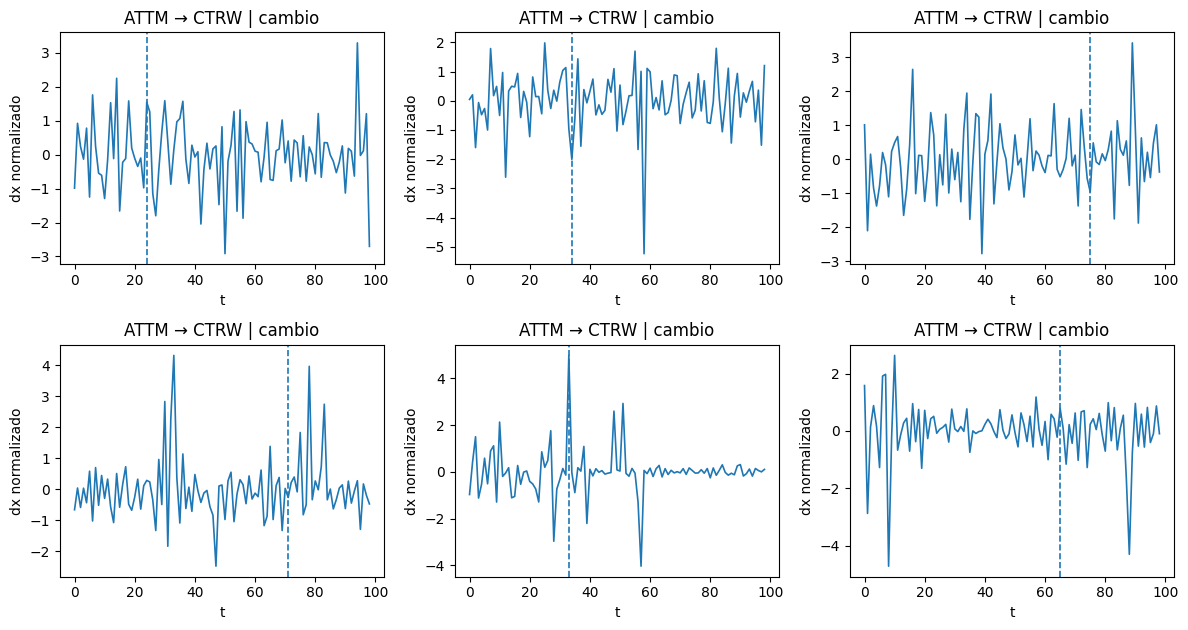

In [10]:
def plot_dx_examples(file_path, n_examples=6):
    if not file_path.exists():
        print(f"Archivo no disponible: {file_path}")
        return

    with h5py.File(file_path, "r") as file:
        n_examples = min(n_examples, len(file["dx"]))
        dx = normalize_dx(file["dx"][:n_examples])
        has_cp = file["has_changepoint"][:n_examples]
        cp_dx = file["cp_dx"][:n_examples]
        model1 = file["model1"][:n_examples]
        model2 = file["model2"][:n_examples]

    columns = 3
    rows = int(np.ceil(n_examples / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(12, 3.2 * rows), squeeze=False)
    axes = axes.ravel()

    for i in range(n_examples):
        axes[i].plot(dx[i, :, 0], linewidth=1.2)
        if has_cp[i] == 1:
            axes[i].axvline(cp_dx[i], linestyle="--", linewidth=1.2)
        title = f"{ID_TO_MODEL[int(model1[i])]} → {ID_TO_MODEL[int(model2[i])]}"
        title += " | cambio" if has_cp[i] else " | sin cambio"
        axes[i].set_title(title)
        axes[i].set_xlabel("t")
        axes[i].set_ylabel("dx normalizado")

    for j in range(n_examples, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

plot_dx_examples(dataset_files["train"], n_examples=6)

## 10. Síntesis metodológica

Este conjunto sintético amplía la fase experimental anterior al incorporar trayectorias homogéneas sin punto de cambio. La formulación resultante permite evaluar simultáneamente la detección binaria, mediante la etiqueta `has_changepoint`, y la localización temporal, mediante `cp_dx_norm` cuando existe una transición real.

El uso de `dx(t)` como entrada favorece el análisis de variaciones locales de la dinámica y reduce la dependencia directa de la posición absoluta. Esta estructura constituye la base común para comparar distintas arquitecturas neuronales en la segunda fase del proyecto.